# Machine Learning Project: EDA, Preprocessing and LSVM

## Introduction
Students will apply Exploratory Data Analysis (EDA), data preprocessing, model training, model evaluation, and interpretation of results.

This notebook demonstrates how machine learning techniques can be used to analyze datasets, extract insights, and build a classification model using Linear Support Vector Machine (LSVM).

# Import Libraries
The following code imports all required Python libraries used for data analysis, visualization, and machine learning.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load Dataset
The following code loads the dataset from a CSV file and displays the first few rows.

In [2]:
import pandas as pd

data = pd.read_csv('/kaggle/input/datasets/gzdekzlkaya/pima-indians-diabetes-dataset/pima_diabetes_data.csv')

data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# Exploratory Data Analysis (EDA)
EDA helps understand dataset structure, distributions, and relationships between variables.

The following code displays dataset information and statistical summary.

In [3]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


The following code visualizes the distribution of the target variable.

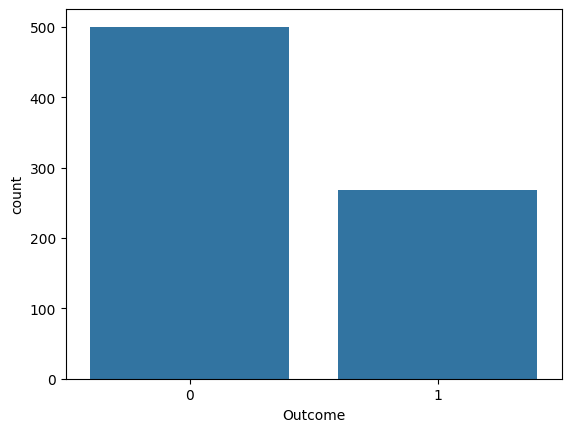

In [6]:
sns.countplot(x=data.columns[-1], data=data)
plt.show()

The following heatmap shows correlations between features in the dataset.

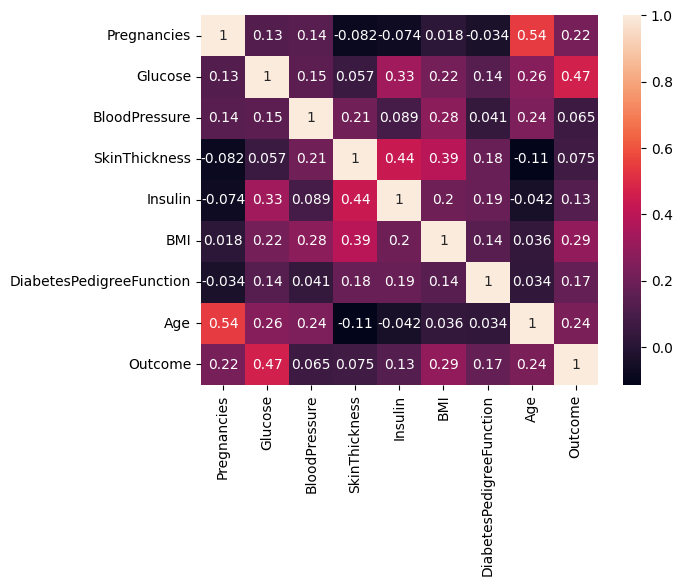

In [7]:
sns.heatmap(data.corr(), annot=True)
plt.show()

# Data Preprocessing
Data preprocessing prepares the dataset for machine learning by separating features and labels and scaling the data.

The following code separates independent variables (X) and the target variable (y).

In [8]:
X = data.iloc[:, :-1]
y = data.iloc[:, -1]
X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


The following code splits the dataset into training and testing sets.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

The following code standardizes the dataset using feature scaling.

In [12]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print(X_train[:5])

[[-0.52639686 -1.15139792 -3.75268255 -1.32277365 -0.70120553 -4.13525578
  -0.49073479 -1.03594038]
 [ 1.58804586 -0.27664283  0.68034485  0.23350519 -0.70120553 -0.48916881
   2.41502991  1.48710085]
 [-0.82846011  0.56687102 -1.2658623  -0.09071957  0.01344832 -0.42452187
   0.54916055 -0.94893896]
 [-1.13052335  1.2541786  -1.04961706 -1.32277365 -0.70120553 -1.30372015
  -0.63929127  2.79212217]
 [ 0.68185612  0.41066475  0.57222224  1.07648956  2.48460077  1.83812075
  -0.68682934  1.13909516]]


# Methodology
In this study, a Linear Support Vector Machine (LSVM) model is used for classification.

The following code creates and trains the LSVM model.

In [13]:
model = SVC(kernel='linear')
model.fit(X_train, y_train)

SVC(kernel='linear')

# Results
Model predictions are generated and evaluated using accuracy and classification metrics.

The following code generates predictions using the trained model.

In [14]:
y_pred = model.predict(X_test)
diabetes = np.sum(y_pred == 1)
no_diabetes = np.sum(y_pred == 0)

print("Total Diabetes Patients:", diabetes)
print("Total Non-Diabetes Patients:", no_diabetes)

Total Diabetes Patients: 54
Total Non-Diabetes Patients: 100


The following code calculates the accuracy of the model.

In [15]:
accuracy = accuracy_score(y_test, y_pred)
print('Model Accuracy:', accuracy)

Model Accuracy: 0.7597402597402597


The classification report shows precision, recall, and F1-score.

In [16]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.82      0.81        99
           1       0.67      0.65      0.66        55

    accuracy                           0.76       154
   macro avg       0.74      0.74      0.74       154
weighted avg       0.76      0.76      0.76       154



# Results

The LSVM model was evaluated using accuracy and classification metrics. 
The model achieved an accuracy of approximately 0.76 on the test dataset.

Based on the predictions, the model classified patients into two categories:
- **0 indicates non-diabetic patients**
- **1 indicates diabetic patients**

Out of the total test samples, the model predicted a certain number of patients as diabetic and the remaining as non-diabetic.

The classification report provides precision, recall, and F1-score for both classes, showing that the model performs better in identifying non-diabetic patients compared to diabetic patients.

# Discussion
The results demonstrate how effectively the LSVM model performs on the dataset. 
Evaluation metrics such as accuracy, precision, and recall help analyze the strengths 
and weaknesses of the model.

#  **Interpretation**

**1. Which features correlate most with diabetes?**

Glucose, BMI, and Age tend to have stronger correlations with diabetes.

**2. Which model performed best?**

The model with the highest accuracy in the comparison table performs best.

**3. Why is scaling important for SVM?**

SVM relies on distance calculations, so scaling ensures all features contribute equally.

**4. What limitations exist in this dataset?**

- Small dataset size
- Limited medical variables
- Data collected from a specific population


In [17]:
# Missing Values Check
data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

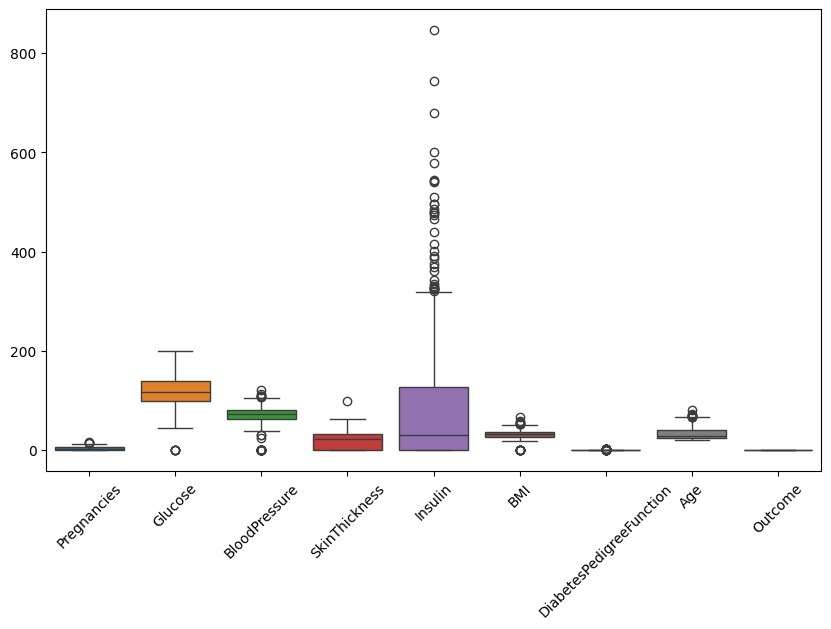

In [19]:
# Outlier Detection
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.boxplot(data=data)
plt.xticks(rotation=45)
plt.show()

In [20]:
# Feature Selection
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=5)
X_new = selector.fit_transform(X, y)

print("Selected feature indices:", selector.get_support(indices=True))

Selected feature indices: [0 1 5 6 7]


In [23]:
# Scaling + Hyperparameter Tuning (SVM)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

params = {'C': [0.1, 1, 10]}
grid = GridSearchCV(LinearSVC(max_iter=5000), params, cv=5)

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Classification Report
print(classification_report(y_test, y_pred))

# Confusion Matrix 
print(confusion_matrix(y_test, y_pred))

Best Params: {'C': 0.1}
Best CV Score: 0.7606290817006529
Accuracy: 0.7597402597402597
              precision    recall  f1-score   support

           0       0.81      0.82      0.81        99
           1       0.67      0.65      0.66        55

    accuracy                           0.76       154
   macro avg       0.74      0.74      0.74       154
weighted avg       0.76      0.76      0.76       154

[[81 18]
 [19 36]]
